# 02. Feature Engineering

**Proyecto**: Pronóstico de demanda multi-series (Curso II — Especialización ML Engineering)

En este notebook se convierte el **subconjunto de 150 series** (store, item, date, sales) en
un dataset **supervisado de regresión** agregando:

- **Features de calendario**: `year`, `month`, `day`, `dayofweek`, `weekofyear`, `dayofyear`.
- **Lags** del target: ventas de hace 1, 7 y 30 días (`lag_1`, `lag_7`, `lag_30`).
- **Estadísticas móviles** por serie: media y desviación de la última semana y del último mes.

> Importante: lags y rolling usan `shift(1)` (solo valores pasados) para **no fugarse
> información del día que se predice**.

> **Corrección (sesión 2)**: las features se construyen sobre la **serie completa ANTES del
> split temporal**. Así el holdout conserva los 90 días completos con lags/variables móviles
> válidos, en lugar de perder las primeras filas por NaN al construirlas solo sobre el holdout.

El módulo reutilizable vive en `src/features/build_features.py` y este notebook solo lo usa.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.features.build_features import build_features, FEATURE_COLUMNS

sns.set_theme()
pd.set_option("display.float_format", "{:.2f}".format)

PROCESSED = Path("../data/processed")
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
print("OK")

OK


## 1. Carga del subconjunto (train + holdout)

Se cargan `train.csv` y `holdout.csv` del subconjunto y se **concatenan** para reconstruir
la serie completa (2013-01-01 a 2017-12-31).

In [2]:
train = pd.read_csv(PROCESSED / "train.csv", parse_dates=["date"])
holdout = pd.read_csv(PROCESSED / "holdout.csv", parse_dates=["date"])
full = pd.concat([train, holdout]).sort_values(["store", "item", "date"]).reset_index(drop=True)

print(f"train: {len(train):,} filas | holdout: {len(holdout):,} filas | serie completa: {len(full):,}")
print(f"Series: {full['store'].nunique()} tiendas x {full['item'].nunique()} items")
full.head()

train: 260,100 filas | holdout: 13,800 filas | serie completa: 273,900
Series: 10 tiendas x 15 items


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 2. Construcción de features sobre la serie completa

`build_features` agrega calendario + lags + rolling **dentro de cada serie**. Al aplicarla a la
serie completa (antes del split), los días del holdout tienen su historial anterior disponible
y no se pierden filas.

In [3]:
featured = build_features(full)
featured.head()

,date,store,item,sales,year,month,day,dayofweek,weekofyear,dayofyear,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30
0,2013-01-01,1,1,13,2013,1,1,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,1,2,13.00,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,1,3,11.00,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,1,4,14.00,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,1,5,13.00,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print(f"Columnas nuevas: {sorted(set(featured.columns) - set(full.columns))}")
print(f"Nuevas dimensiones: {featured.shape}")

Columnas nuevas: ['day', 'dayofweek', 'dayofyear', 'lag_1', 'lag_30', 'lag_7', 'month', 'rolling_mean_30', 'rolling_mean_7', 'rolling_std_30', 'rolling_std_7', 'weekofyear', 'year']
Nuevas dimensiones: (273900, 17)


## 3. Manejo de valores nulos (lags y rolling)

Los NaN solo aparecen al **inicio de cada serie** (enero 2013, sin historial previo para
lags/rolling). Se eliminan del train; el holdout queda completo.

In [5]:
nulls = featured.isna().sum()
null_cols = nulls[nulls > 0]
print(null_cols.to_string())
print(f"\nFilas sin NaN (útiles para entrenar): {featured.dropna().shape[0]:,} de {len(featured):,} "
      f"({featured.dropna().shape[0]/len(featured)*100:.1f}%)")

lag_1               150
lag_7              1050
lag_30             4500
rolling_mean_7     1050
rolling_std_7      1050
rolling_mean_30    4500
rolling_std_30     4500

Filas sin NaN (útiles para entrenar): 269,400 de 273,900 (98.4%)


In [6]:
TRAIN_CUTOFF = "2017-09-30"

# Split temporal DESPUÉS de construir las features sobre la serie completa
train_feat = featured[featured["date"] <= TRAIN_CUTOFF].dropna().reset_index(drop=True)
holdout_feat = featured[featured["date"] > TRAIN_CUTOFF].reset_index(drop=True)

print(f"train   con features: {len(train_feat):,} filas")
print(f"holdout con features: {len(holdout_feat):,} filas")
print(f"Holdout con NaN (debe ser 0): {int(holdout_feat.isna().sum().sum())}")
print(f"Rango holdout: {holdout_feat['date'].min().date()} a {holdout_feat['date'].max().date()}")
print(f"Series en holdout: {holdout_feat.groupby(['store','item']).ngroups}")

train   con features: 255,600 filas
holdout con features: 13,800 filas
Holdout con NaN (debe ser 0): 0
Rango holdout: 2017-10-01 a 2017-12-31
Series en holdout: 150


## 4. Distribución y correlación de features

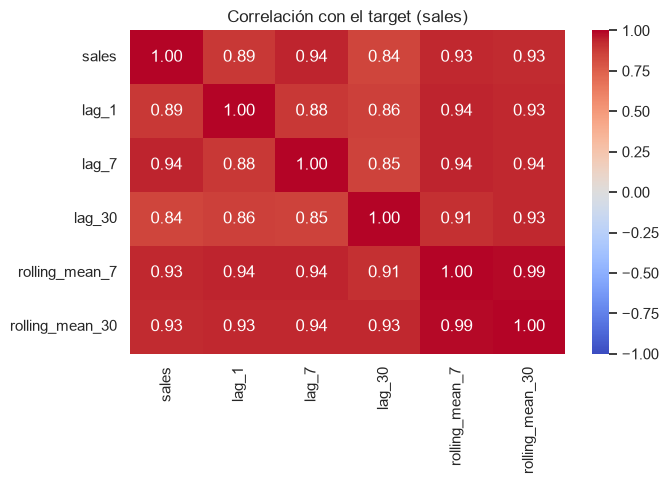

In [7]:
corr = train_feat[["sales", "lag_1", "lag_7", "lag_30", "rolling_mean_7", "rolling_mean_30"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlación con el target (sales)")
plt.tight_layout(); plt.savefig(FIGURES / "correlacion_features.png", dpi=150); plt.show()

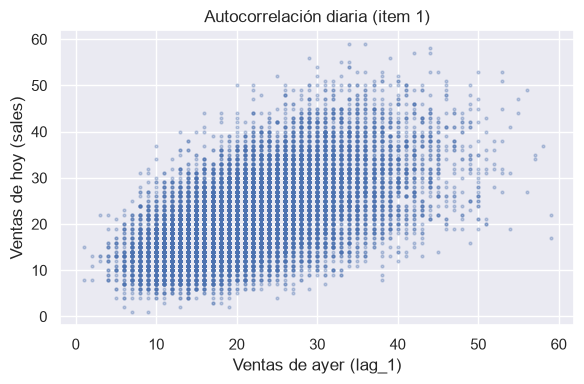

In [8]:
# Relación lag_1 vs ventas reales (muestra de 5 series)
sample = train_feat[train_feat["item"] == 1]
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sample["lag_1"], sample["sales"], s=4, alpha=0.3)
ax.set_xlabel("Ventas de ayer (lag_1)")
ax.set_ylabel("Ventas de hoy (sales)")
ax.set_title("Autocorrelación diaria (item 1)")
fig.tight_layout(); fig.savefig(FIGURES / "scatter_lag1.png", dpi=150); plt.show()

## 5. Guardado

Se guardan las features del **subconjunto** para la Fase 3. El holdout conserva los
**92 días completos** (13,800 filas) con lags válidos.

In [9]:
train_feat.to_csv(PROCESSED / "train_features.csv", index=False)
holdout_feat.to_csv(PROCESSED / "holdout_features.csv", index=False)
print("Guardado: data/processed/train_features.csv y holdout_features.csv")
for f in ["train_features.csv", "holdout_features.csv"]:
    p = PROCESSED / f
    print(f"  {f:24s} {(p.stat().st_size / 1e6):6.2f} MB")

Guardado: data/processed/train_features.csv y holdout_features.csv
  train_features.csv        30.91 MB
  holdout_features.csv       1.69 MB


## Conclusiones

- Se convirtió el subconjunto de 150 series en un problema supervisado con 11 features por fila.
- **Corrección clave**: las features se construyen sobre la serie completa ANTES del split, así
  el holdout (oct–dic 2017) conserva los 92 días completos con lags válidos (0 NaN).
- `lag_1`, `rolling_mean_7` y `rolling_mean_30` tienen la correlación más alta con el target.
- Los datos listos para modelar quedan en `data/processed/*_features.csv`; las columnas
  `store` y `item` se usarán como categóricas en los modelos de gradiente boosting.
